In [2]:
import pandas as pd
import numpy as np

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
columns = ['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration', 
           'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 
           'length', 'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders', 
           'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio', 
           'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']

df = pd.read_csv(url, names=columns, na_values='?')

print(df.shape)
print(df.isnull().sum())

# Export to CSV
df.to_csv("autos_cleaned.csv", index=False)

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1081)>

In [3]:
# read csv file
df = pd.read_csv("autos_cleaned.csv")
print(df.head())

   symboling  normalized-losses         make fuel-type aspiration  \
0          3                NaN  alfa-romero       gas        std   
1          3                NaN  alfa-romero       gas        std   
2          1                NaN  alfa-romero       gas        std   
3          2              164.0         audi       gas        std   
4          2              164.0         audi       gas        std   

  num-of-doors   body-style drive-wheels engine-location  wheel-base  ...  \
0          two  convertible          rwd           front        88.6  ...   
1          two  convertible          rwd           front        88.6  ...   
2          two    hatchback          rwd           front        94.5  ...   
3         four        sedan          fwd           front        99.8  ...   
4         four        sedan          4wd           front        99.4  ...   

   engine-size  fuel-system  bore  stroke compression-ratio horsepower  \
0          130         mpfi  3.47    2.68       

In [4]:
# Before: some horsepower missing
print(df['horsepower'].mean())   # e.g., around 104

# Impute with mean
df['horsepower_mean'] = df['horsepower'].fillna(df['horsepower'].mean())

# Or in one line
df['horsepower'].fillna(df['horsepower'].mean(), inplace=True)

104.25615763546799


In [5]:
median_price = df['price'].median()
df['price'].fillna(median_price, inplace=True)

In [6]:
mode_doors = df['num-of-doors'].mode()[0]   # e.g., 'four'
df['num-of-doors'].fillna(mode_doors, inplace=True)

In [7]:
# Fill normalized-losses with mean of same 'make'
df['normalized-losses'] = df.groupby('make')['normalized-losses'].transform(lambda x: x.fillna(x.mean()))

# Alternative: fill price with median of same body-style
df['price'] = df.groupby('body-style')['price'].transform(lambda x: x.fillna(x.median()))

In [8]:
df['price'].fillna(method='ffill', inplace=True)  # Use previous value
# or 'bfill' for next value

/var/folders/f3/3kqpjfqj03s00nxsf6rppv280000gn/T/ipykernel_2324/3322680358.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['price'].fillna(method='ffill', inplace=True)  # Use previous value


In [9]:
from sklearn.impute import KNNImputer

# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])
imputer = KNNImputer(n_neighbors=5)
df_numeric_imputed = pd.DataFrame(imputer.fit_transform(numeric_df), columns=numeric_df.columns)

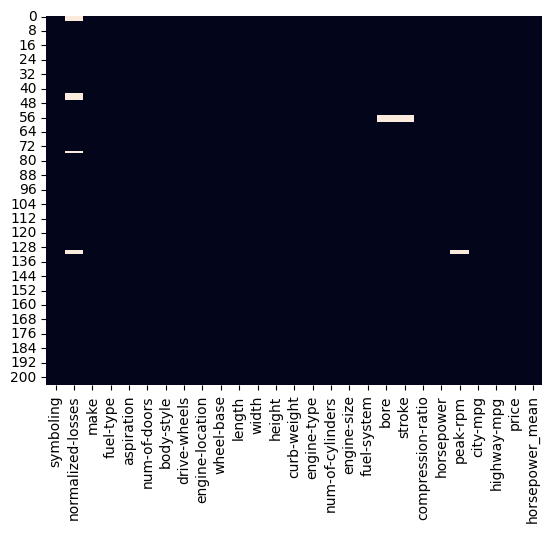

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df.isnull(), cbar=False)
plt.show()

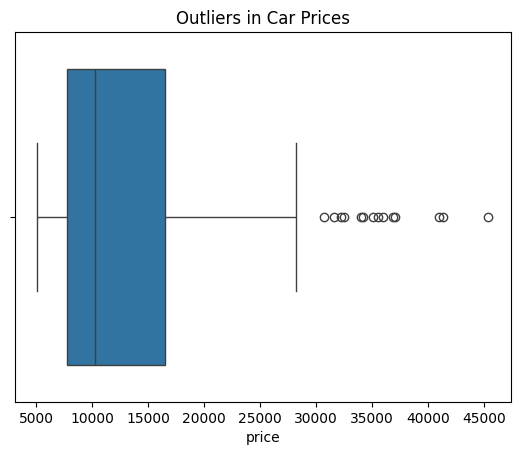

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['price'])
plt.title("Outliers in Car Prices")
plt.show()

In [12]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Find outliers
outliers = df[(df['price'] < lower) | (df['price'] > upper)]

print("Number of outliers in price:", len(outliers))
print("Expensive outlier cars:", outliers['make'].values)

Number of outliers in price: 14
Expensive outlier cars: ['bmw' 'bmw' 'bmw' 'jaguar' 'jaguar' 'jaguar' 'mercedes-benz'
 'mercedes-benz' 'mercedes-benz' 'mercedes-benz' 'mercedes-benz' 'porsche'
 'porsche' 'porsche']
